# Assessment Notebook

This notebook implements the final three trading signals selected in the research notebook and evaluates the resulting combined trading strategy. The parameters are not re-estimated here; they are taken from the in-sample research process found in the research notebook and applied directly in the assessment period.

The empirical parameter selection, in-sample calibration, out-of-sample validation and literature motivation are documented in the separate research notebook. This assessment notebook focuses on applying the final selected signals, constructing the combined portfolio, and evaluating the resulting strategy with meaningful statistics and graphs.

The final signals are:

1. **Signal 0:** SPY / VIX term-structure signal.
2. **Signal 1:** XLE / Oil relative-strength signal.
3. **Signal 2:** GLD / Gold safe-haven signal.

The notebook first downloads the required market data, then computes the three signals, builds the combined portfolio, calculates performance statistics and finally visualizes the strategy behaviour.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import importlib
import module
importlib.reload(module)

<module 'module' from 'c:\\Users\\22eli\\Documents\\Tübingen\\Uni Tübingen\\Computational Finance\\CURRENT VERSION\\module.py'>

# 1. Data Preparation

This section downloads the traded ETFs and the information variables used by the signals. The traded assets are SPY, XLE and GLD. AOR is used as the benchmark for the combined strategy.

## Benchmark and data-source note

AOR is used as the benchmark because the final strategy is not a pure equity strategy. The strategy combines exposure to the S&P 500 via the SPY ETF, The U.S. Energy Sector represented by the XLE ETF, as well as Gold via the GLD ETF and cash. Henceforth, a diversified allocation ETF is more comparable than a single-equity benchmark such as SPY. AOR invests around 60% in equities, 39% in Fixed Income assets and around 1% in Cash and/or Derivatives. However, AOR is still not a perfect benchmark because the strategy is dynamic, signal-based and can hold a large cash position.

The crude-oil input `CL=F` is used as a proxy for the oil-market environment in Signal 1. Futures data can be affected by contract rolls, changing term structures and Yahoo Finance data conventions. Therefore, `CL=F` should be interpreted as an information variable for oil-market conditions rather than as a directly traded spot-oil investment.

In [2]:
# DOWNLOAD DATA

benchmark_ticker = "AOR"

download_tickers = [
    "SPY",
    "XLE",
    "GLD",
    benchmark_ticker
]

tickers = [
    "SPY_VIX",
    "XLE_OIL",
    "GLD_GOLD",
    benchmark_ticker
]

vix_ticker = "^VIX"
vix3m_ticker = "^VIX3M"
oil_ticker = "CL=F"
bond_ticker = "TLT"

indicator_tickers = [
    vix_ticker,
    vix3m_ticker,
    oil_ticker,
    bond_ticker
]

start_date = "2015-01-01"
end_date = "2025-12-31"

df_downloaded_prices, _ = module.download_stock_price_data(
    download_tickers,
    start_date,
    end_date
)

df_indicator_prices, _ = module.download_stock_price_data(
    indicator_tickers,
    start_date,
    end_date
)

common_index = df_downloaded_prices.index.intersection(
    df_indicator_prices.index
)

df_downloaded_prices = df_downloaded_prices.loc[common_index]
df_indicator_prices = df_indicator_prices.loc[common_index]

df_prices = pd.DataFrame(index=common_index)

df_prices["SPY_VIX"] = df_downloaded_prices["SPY"]
df_prices["XLE_OIL"] = df_downloaded_prices["XLE"]
df_prices["GLD_GOLD"] = df_downloaded_prices["GLD"]
df_prices[benchmark_ticker] = df_downloaded_prices[benchmark_ticker]

df_price_changes = module.price_changes_from_price_frame(df_prices)

print("First common date:", df_prices.index.min())
print("Last common date:", df_prices.index.max())

df_prices.tail()


First common date: 2015-01-02 00:00:00
Last common date: 2025-12-30 00:00:00


,SPY_VIX,XLE_OIL,GLD_GOLD,AOR
date,,,,
2025-12-23,684.323303,43.894577,413.640015,64.908707
2025-12-24,686.730530,43.766350,411.929993,65.097801
2025-12-26,686.660889,43.598663,416.739990,65.127663
2025-12-29,684.213867,44.012947,398.600006,65.038086
2025-12-30,683.378357,44.348324,398.890015,65.008232


# 2. Trading Signals

The following cells define the three final signal functions. The assessment notebook uses fixed parameter values that were selected in the research notebook. This keeps the out-of-sample assessment separate from the parameter search.

In [3]:
# DEFINE THREE TRADING SIGNALS

# Signal 0:
# Trades SPY using VIX term structure and SPY momentum.

# Signal 1:
# Trades XLE using crude oil momentum, XLE trend, XLE momentum,
# and XLE relative strength versus SPY.

# Signal 2:
# Trades GLD using gold trend, gold momentum, and Treasury bond momentum.


## Signal 0: SPY / VIX Term-Structure Signal

The strategy trades SPY, which is an S&P 500 ETF. The VIX index and the VIX3M index are not traded directly; they are only used as information variables.

The economic idea is that the VIX term structure contains information about the equity-market risk regime. The VIX is the Cboe Volatility Index, which measures the expected 30-day volatility of the S&P 500 via S&P 500 index option prices. The VIX3M measures the 3-month expected S&P 500 volatility, respectively. The signal is active when the VIX3M/VIX ratio is above the selected threshold and SPY momentum is not too weak. This means the strategy buys SPY only when the volatility environment is sufficiently normal and the underlying equity market does not show strong medium-term weakness.

The VIX term-structure ratio is defined as:

$$
R_t^{VIX}=\frac{VIX3M_t}{VIX_t}
$$

The SPY momentum filter is:

$$
M_t^{SPY}=\frac{SPY_t}{SPY_{t-168}}-1
$$

The final signal is:

$$
S_t^{SPY}=\begin{cases}
1, & \text{if } R_t^{VIX}>1.10 \text{ and } M_t^{SPY}>-0.025 \\
0, & \text{otherwise}
\end{cases}
$$

A signal value of 1 means the strategy is invested in the asset, while a signal value of 0 means the strategy is out of the asset and holds cash.

In [4]:
signal_0_ratio_threshold = 1.10
signal_0_momentum_window = 168
signal_0_momentum_threshold = -0.025


def signal_0(series):

    return module.vix_term_structure_signal(
        target_series=series,
        vix_series=df_indicator_prices[vix_ticker],
        vix3m_series=df_indicator_prices[vix3m_ticker],
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )

## Signal 1: Oil / Energy Relative-Strength Signal

The strategy trades XLE, which is State Street® Energy Select Sector SPDR® ETF that aims to track the performance of the energy sector within the S&P 500 universe. Crude oil futures and SPY are not traded directly; they are only used as information variables.

The signal is active when XLE is in an upward trend, crude oil momentum is not too weak, XLE has positive own momentum, and XLE does not strongly underperform SPY. The aim is to hold energy equities only when both the sector itself and the oil-related market environment are supportive.

The XLE trend filter is:

$$
XLE_t>MA_t^{XLE,200}
$$

The oil and XLE momentum filters are:

$$
M_t^{Oil}=\frac{Oil_t}{Oil_{t-126}}-1>-0.05
$$

$$
M_t^{XLE}=\frac{XLE_t}{XLE_{t-210}}-1>0
$$

Relative strength is measured against SPY:

$$
RS_t^{XLE/SPY}=\frac{XLE_t}{SPY_t}
$$

$$
M_t^{RS}=\frac{RS_t^{XLE/SPY}}{RS_{t-21}^{XLE/SPY}}-1>-0.025
$$

The final signal is:

$$
S_t^{XLE}=\begin{cases}
1, & \text{if all four conditions are satisfied} \\
0, & \text{otherwise}
\end{cases}
$$


In [5]:
signal_1_trend_window = 200

signal_1_oil_momentum_window = 126
signal_1_oil_momentum_threshold = -0.05

signal_1_target_momentum_window = 210
signal_1_target_momentum_threshold = 0.0

signal_1_relative_strength_window = 21
signal_1_relative_strength_threshold = -0.025


def signal_1(series):

    return module.oil_energy_relative_strength_signal(
        target_series=series,
        oil_series=df_indicator_prices[oil_ticker],
        market_series=df_downloaded_prices["SPY"],
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )

## Signal 2: Gold Safe-Haven Signal

The strategy trades GLD, which is the first U.S. traded gold ETF that aims to reflect the performance of Gold bullion. TLT is the iShares 20+ Year Treasury Bond ETF which is not traded directly; it is only used as an information variable for the bond and interest-rate environment.

The signal is active when GLD is above its long-term moving average, GLD has positive medium-term momentum, and TLT momentum is not strongly negative. Gold is included because it adds a different return driver to the equity-oriented SPY and XLE signals.

The GLD trend filter is:

$$
GLD_t>MA_t^{GLD,100}
$$

The GLD and TLT momentum filters are:

$$
M_t^{GLD}=\frac{GLD_t}{GLD_{t-63}}-1>0
$$

$$
M_t^{TLT}=\frac{TLT_t}{TLT_{t-63}}-1>-0.02
$$

The final signal is:

$$
S_t^{GLD}=\begin{cases}
1, & \text{if } GLD_t>MA_t^{GLD,100},\ M_t^{GLD}>0,\ \text{and } M_t^{TLT}>-0.02 \\
0, & \text{otherwise}
\end{cases}
$$


In [6]:
signal_2_trend_window = 100
signal_2_momentum_window = 63
signal_2_gld_momentum_threshold = 0.0
signal_2_tlt_momentum_threshold = -0.02


def signal_2(series):

    return module.gold_safe_haven_signal(
        gld_series=series,
        tlt_series=df_indicator_prices[bond_ticker],
        trend_window=signal_2_trend_window,
        momentum_window=signal_2_momentum_window,
        gld_momentum_threshold=signal_2_gld_momentum_threshold,
        tlt_momentum_threshold=signal_2_tlt_momentum_threshold
    )


In [7]:
signals = {
    tickers[0]: signal_0(df_prices[tickers[0]]),
    tickers[1]: signal_1(df_prices[tickers[1]]),
    tickers[2]: signal_2(df_prices[tickers[2]])
}

execution_delay_days = 1

for ticker in tickers[:-1]:

    signals[ticker] = module.apply_execution_delay(
        signals[ticker],
        delay_days=execution_delay_days
    )

df_position_open = pd.concat([
    signals[tickers[0]]["signal"].rename(tickers[0]),
    signals[tickers[1]]["signal"].rename(tickers[1]),
    signals[tickers[2]]["signal"].rename(tickers[2])
], axis=1)

df_position_changes = pd.concat([
    signals[tickers[0]]["position_change"].rename(tickers[0]),
    signals[tickers[1]]["position_change"].rename(tickers[1]),
    signals[tickers[2]]["position_change"].rename(tickers[2])
], axis=1)

df_position_open.tail()

,SPY_VIX,XLE_OIL,GLD_GOLD
date,,,
2025-12-23,1.0,0.0,1.0
2025-12-24,1.0,0.0,1.0
2025-12-26,1.0,0.0,1.0
2025-12-29,1.0,0.0,1.0
2025-12-30,1.0,0.0,1.0


# 3. Portfolio Construction

The three binary signals are combined into one long-only portfolio. A fixed fraction of available capital is allocated when a signal opens, positions are held while the signal remains active, and capital is returned to cash when a signal closes.

The portfolio does not use leverage or short selling. Cash is assumed to earn zero return. Transaction costs, bid-ask spreads and slippage are not deducted in the main backtest, so the reported performance should be interpreted as a gross backtest before implementation costs.

In [8]:
# ALLOCATE CAPITAL AND COMPUTE RESULTING POSITIONS
initial_cash = 1.0
capital_fraction_per_trade = 0.30

# Portfolio mechanics
position = []

def open_trades(position, position_change):
    vec = np.maximum([position_change[ticker] for ticker in tickers[:-1]], [0])
    vec = position[-1] * (1 - np.power((1 - capital_fraction_per_trade), np.sum(vec))) * vec / (1 if (np.nansum(vec) == 0.0) else np.nansum(vec))
    return np.append(vec + position[:-1], position[-1] - np.sum(vec))

def hold_trades(position, price_change):
    return np.concatenate((position[:-1] * price_change[:-1], [position[-1]]))

def close_trades(position, position_change):
    vec = np.concatenate((np.array([position_change[ticker] < 0.0 for ticker in tickers[:-1]]), [False]))
    position[-1] = position[-1] + np.sum(position[vec])
    position[vec] = 0.0
    return position
    
is_first = True
for idx, position_change in df_position_changes.iterrows():
    if is_first:
        position.append(open_trades(np.concatenate((np.zeros(len(df_position_changes.columns)), [initial_cash])), position_change))
        is_first = False
    else:
        hlpr_pos = hold_trades(position[-1], df_price_changes.loc[[idx]].to_numpy()[0])
        hlpr_pos = close_trades(hlpr_pos, position_change)
        position.append(open_trades(hlpr_pos, position_change))

df_position = pd.DataFrame(position, index = df_prices.index, columns = tickers[:-1] + ['cash'])

# 4. Performance Statistics

The combined strategy is compared with the AOR benchmark using annualized return, annualized volatility, Sharpe ratio, Sortino ratio and maximum drawdown. The histogram below adds a more detailed view of the strategy's daily returns. Instead of only looking at one summary number, it shows how often small gains, small losses and larger daily moves occur. This helps to see whether the strategy's performance comes from a stable return distribution or from a few extreme observations. Additional trade-activity statistics are included afterwards to make the strategy's implementation intensity more transparent.

,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Our Strategy,0.0525,0.0506,1.0376,1.4709,-0.0532
Benchmark AOR ETF,0.0711,0.1049,0.7077,0.9815,-0.2295


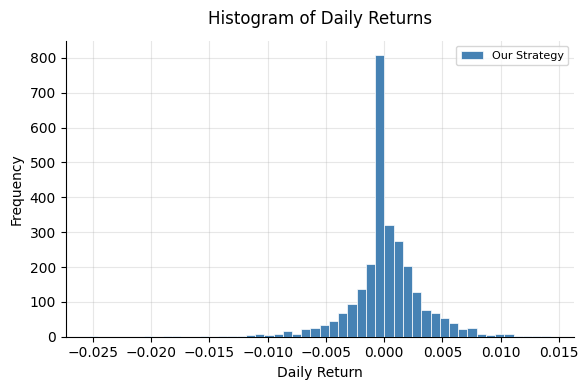

In [9]:
statistics_rows = {}

portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

statistics_rows["Our Strategy"] = (
    module.performance_statistics_from_values(
        portfolio_value
    )
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

statistics_rows["Benchmark AOR ETF"] = (
    module.performance_statistics_from_values(
        benchmark_curve
    )
)

df_statistics = pd.DataFrame(statistics_rows).T

df_statistics = df_statistics[
    [
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown"
    ]
]

display(df_statistics.round(4))


# Histogram
returns = module.portfolio_returns_from_values(portfolio_value)

plt.figure(figsize=(6, 4))

plt.hist(returns, bins=50, color="steelblue", edgecolor="white", linewidth=0.5, zorder=3, label="Our Strategy")
plt.title("Histogram of Daily Returns", pad=12)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3, zorder=0)

plt.gca().spines["top"].set_visible(False)    
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Trade activity and implementation-cost sensitivity

The main performance table is a gross backtest. The following table adds implementation context by reporting how often each signal trades, how often it is active and how sensitive the final portfolio value would be to simple transaction-cost assumptions. This does not replace a full execution-cost model, but it makes the trading intensity transparent.

In [10]:
trade_rows = []

for ticker in tickers[:-1]:
    changes = df_position_changes[ticker]
    signal = df_position_open[ticker]

    buy_trades = int(np.sum(changes == 1.0))
    sell_trades = int(np.sum(changes == -1.0))
    total_trades = buy_trades + sell_trades
    active_share = float(np.mean(signal == 1.0))

    holding_lengths = []
    current_length = 0
    for value in signal.to_numpy(dtype=float):
        if value == 1.0:
            current_length += 1
        elif current_length > 0:
            holding_lengths.append(current_length)
            current_length = 0
    if current_length > 0:
        holding_lengths.append(current_length)

    average_holding_days = np.nan
    if len(holding_lengths) > 0:
        average_holding_days = float(np.mean(holding_lengths))

    trade_rows.append({
        "Signal": ticker,
        "Buy Trades": buy_trades,
        "Sell Trades": sell_trades,
        "Total Trades": total_trades,
        "Active Share": active_share,
        "Avg Holding Days": average_holding_days,
    })

df_trade_activity = pd.DataFrame(trade_rows)
display(df_trade_activity.round(4))

traded_value_proxy = 0.0
previous_position = df_position.iloc[0][tickers[:-1]].to_numpy(dtype=float)

for index in range(1, len(df_position)):
    current_position = df_position.iloc[index][tickers[:-1]].to_numpy(dtype=float)
    traded_value_proxy += np.sum(np.abs(current_position - previous_position))
    previous_position = current_position

cost_rows = []
for cost_bps in [0, 5, 10, 25]:
    cost_rate = cost_bps / 10000
    estimated_cost = traded_value_proxy * cost_rate
    cost_rows.append({
        "Cost per traded value (bps)": cost_bps,
        "Estimated Total Cost": estimated_cost,
        "Final Portfolio Value After Cost": portfolio_value[-1] - estimated_cost,
    })

df_cost_sensitivity = pd.DataFrame(cost_rows)
display(df_cost_sensitivity.round(4))

,Signal,Buy Trades,Sell Trades,Total Trades,Active Share,Avg Holding Days
0,SPY_VIX,118,117,235,0.5758,13.4831
1,XLE_OIL,80,80,160,0.2595,8.9625
2,GLD_GOLD,64,63,127,0.4510,19.4688


,Cost per traded value (bps),Estimated Total Cost,Final Portfolio Value After Cost
0,0,0.0000,1.7604
1,5,0.0865,1.6739
2,10,0.1731,1.5873
3,25,0.4327,1.3277


# 5. Graphical Analysis

The graphs illustrate the portfolio value, drawdowns, rolling risk-adjusted performance, signal activity, capital allocation and buy/sell timing for the three final signals.

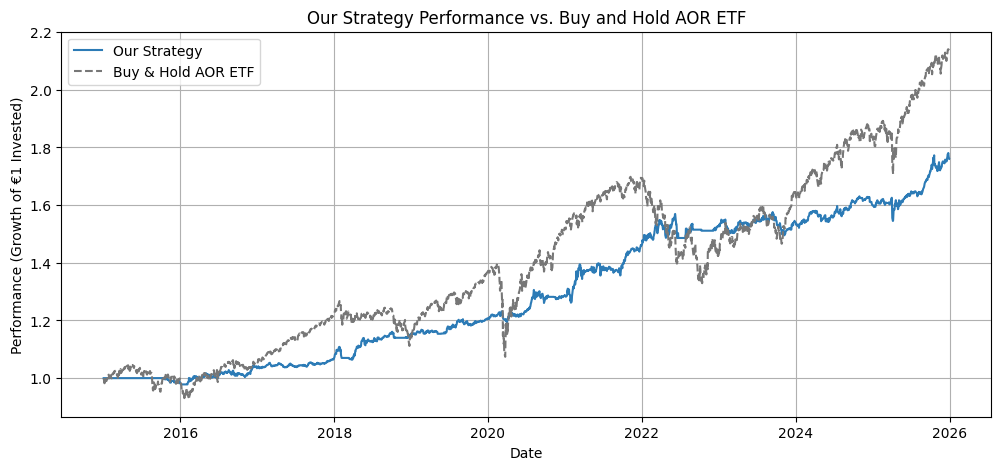

In [11]:
portfolio_value = df_position.sum(axis=1).to_numpy(dtype=float)

portfolio_curve = (
    portfolio_value
    / portfolio_value[0]
)

benchmark_values = df_prices[tickers[-1]].to_numpy(dtype=float)

benchmark_curve = (
    benchmark_values
    / benchmark_values[0]
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_prices.index,
    portfolio_curve,
    label="Our Strategy", 
    color = "#2c7bb6"
)

plt.plot(
    df_prices.index,
    benchmark_curve,
    label="Buy & Hold " + tickers[-1]+ " ETF",
    linestyle="--",
    color = "#777777"
)

plt.title("Our Strategy Performance vs. Buy and Hold AOR ETF") # Out-of sample time
plt.xlabel("Date")
plt.ylabel("Performance (Growth of €1 Invested)")
plt.legend()
plt.grid(True)

plt.show()


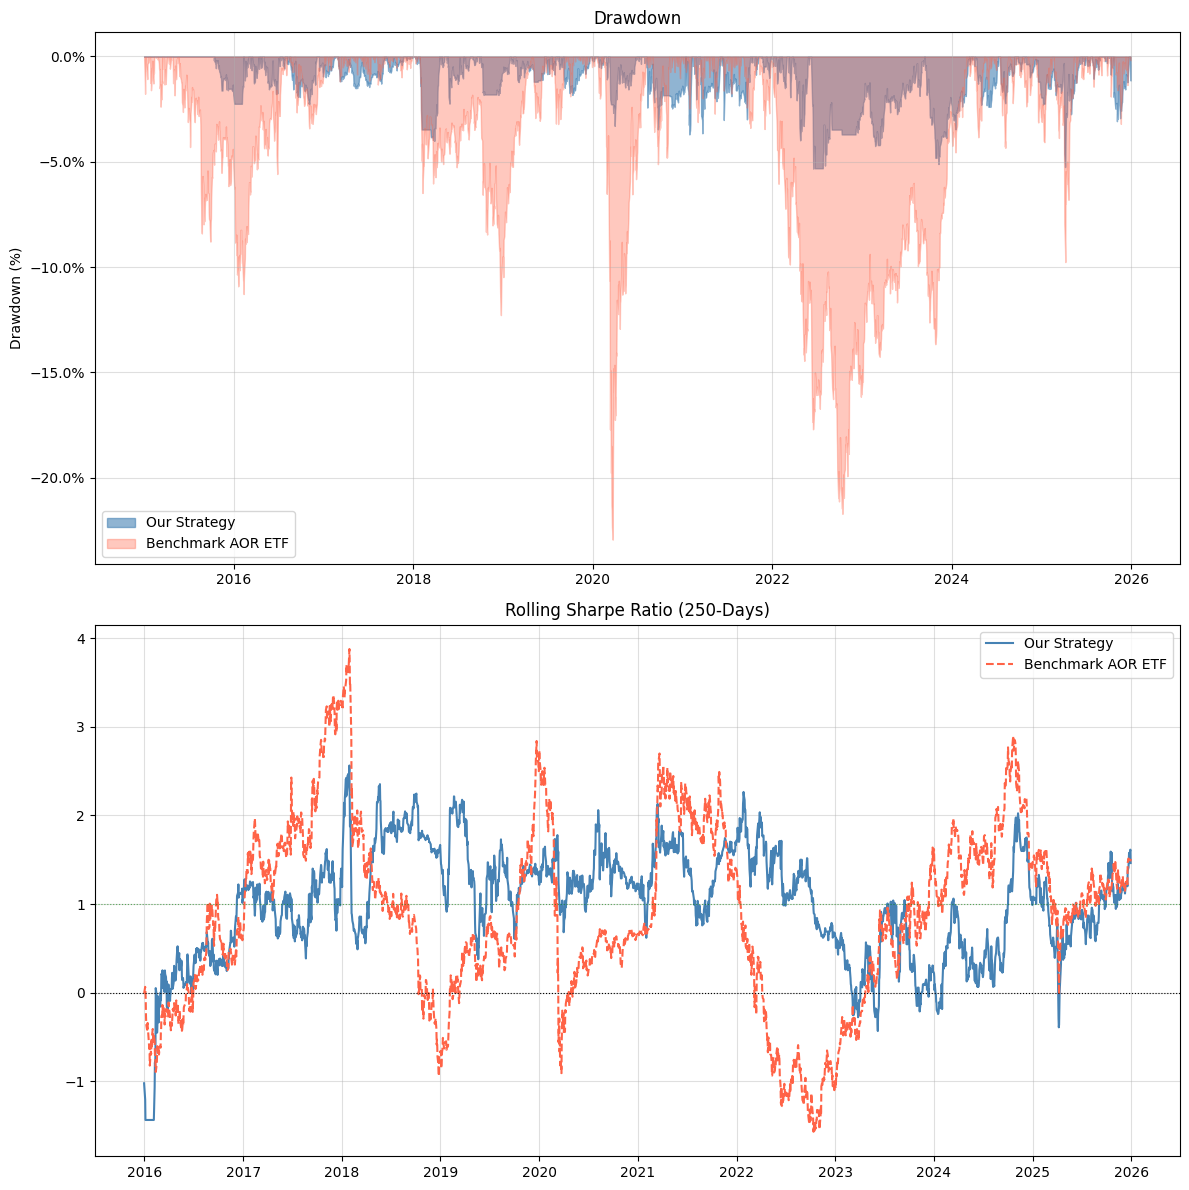

In [12]:
"""This cell gives a risk-focused view of the strategy compared with the AOR benchmark.
 The drawdown plot shows how far each portfolio falls below its previous peak.
 The rolling Sharpe ratio shows how risk-adjusted performance changes over time,
 using a 250-day window as an approximation of one trading year."""

module.plot_drawdown_and_rolling_sharpe(
    portfolio_curve,
    benchmark_curve,
    df_prices.index,
)


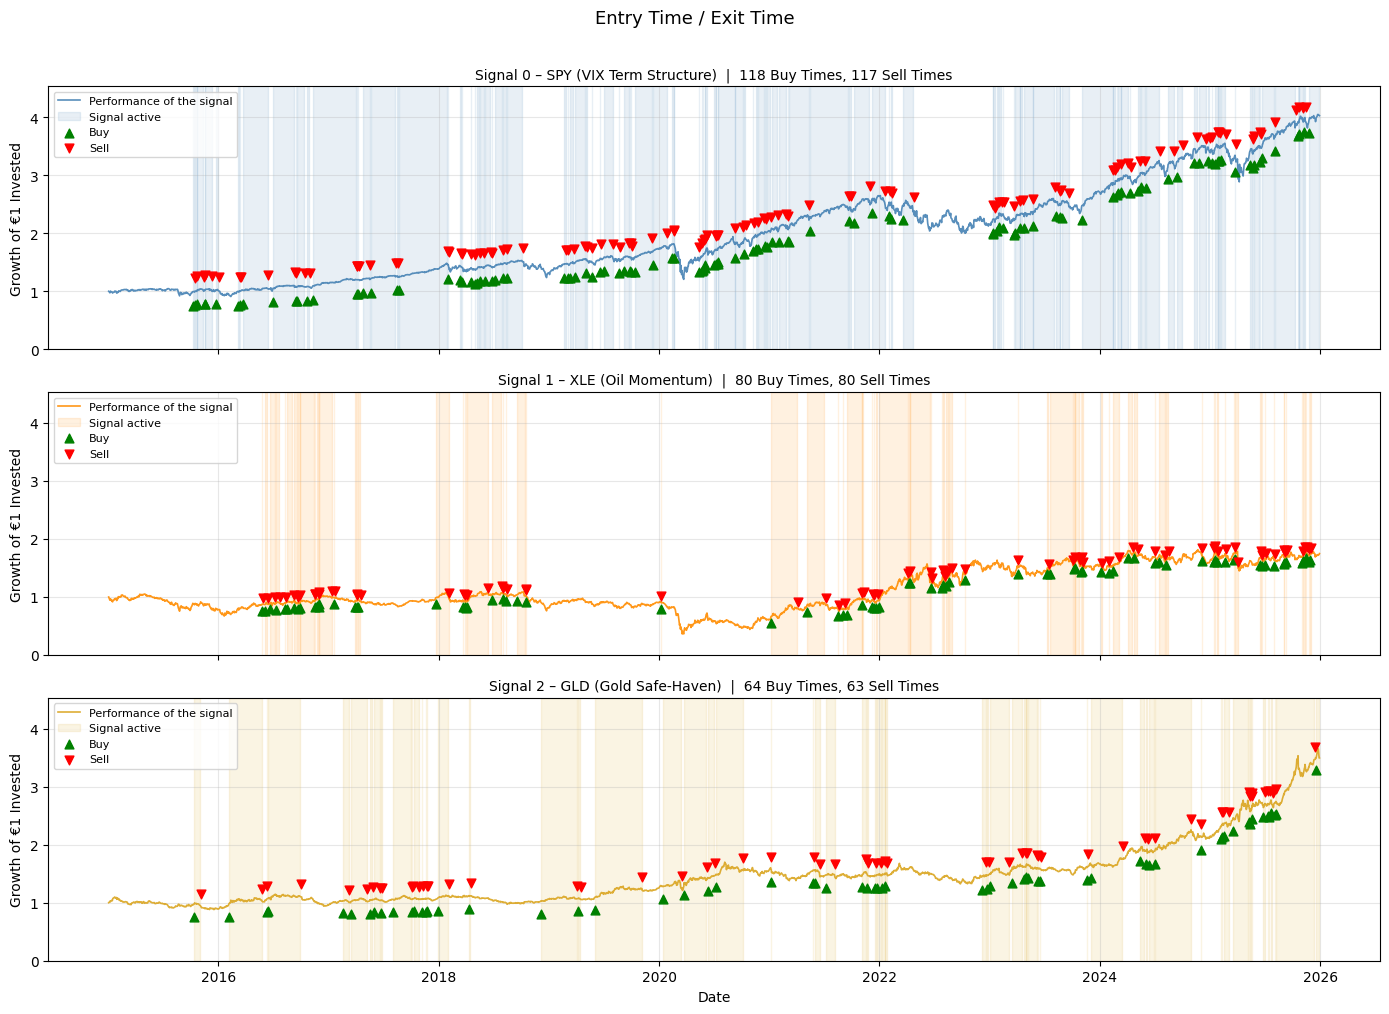

In [13]:
"""Shows when each signal is active and where the strategy enters or exits each ETF.
 Buy markers indicate 0 -> 1 signal changes, while sell markers indicate 1 -> 0 changes."""

module.plot_entry_exit_times(
    tickers,
    df_prices,
    df_position_open,
    df_position_changes,
)


### Signal Value Analysis

The graph shows how each signal would have performed on its own, compared with the final combined strategy and the AOR benchmark. The individual signal lines are not buy-and-hold returns. Each isolated signal uses the same 30% allocation rule as in the portfolio construction, so only part of the available capital is invested when a new position is opened. The lines only increase or decrease when the signal is active and the strategy is invested in that asset. When a signal is inactive, the position is closed and the money remains in cash, which is why some parts of the lines are flat.

The green line shows the combined strategy, where the three signals are used together with the portfolio allocation rule. The grey dashed line shows the AOR benchmark as a simple buy-and-hold comparison. Overall, the graph helps to see how much each signal contributes individually and how the combined strategy behaves relative to the benchmark.

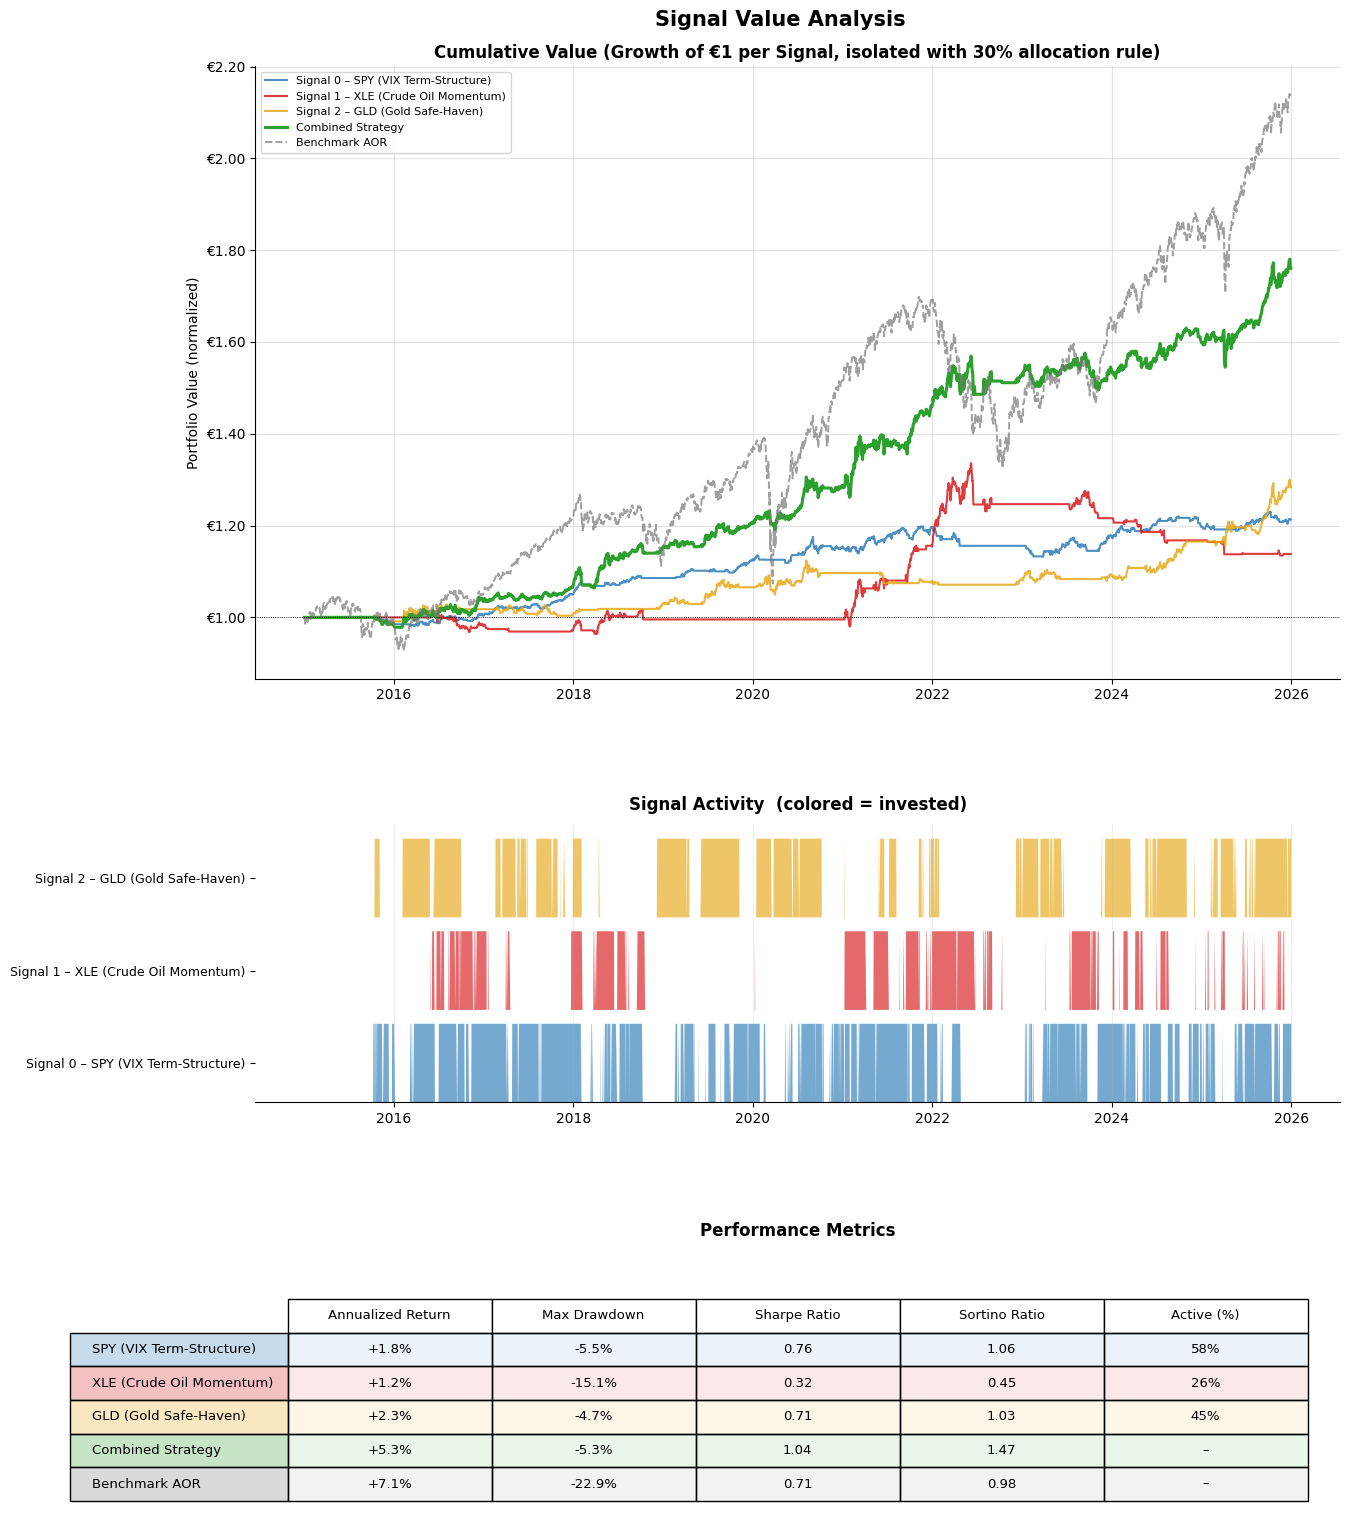

In [14]:

module.plot_signal_value_analysis(
    tickers,
    df_prices,
    df_price_changes,
    df_position_open,
    df_position_changes,
    df_position,
    initial_cash=initial_cash,
)
